In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

g = 9.81  # m/s²

In [30]:
df = pd.read_csv('/Users/Alexander/Repositories/Ocean_MAE_223/Ocean_Test_Success/imuLog00082.csv')
df['time'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M:%S.%f')

# The IMU's RTC boots at the year-2000 default and only jumps to the real
# (GPS-synced) time after a few samples. Those pre-sync rows sit ~26 years
# before the rest of the log, which blows up the t_s axis (and makes the
# FFT window select zero rows). Drop them before building the time axis.
n_pre = int((df['time'].dt.year < 2001).sum())
df = df[df['time'].dt.year >= 2001].reset_index(drop=True)
print(f'Dropped {n_pre} pre-sync (year-2000) rows')

df['t_s'] = (df['time'] - df['time'].iloc[0]).dt.total_seconds()

# Convert accelerations from milli-g to m/s²
df['AccX'] = df['AccX'] / 1000 * g
df['AccY'] = df['AccY'] / 1000 * g
df['AccZ'] = df['AccZ'] / 1000 * g

fs = 1.0 / np.median(np.diff(df['t_s'].values))
print(f'Sample rate: {fs:.2f} Hz,  Duration: {df.t_s.iloc[-1]:.1f} s')

Dropped 0 pre-sync (year-2000) rows
Sample rate: 10.00 Hz,  Duration: 5056.7 s


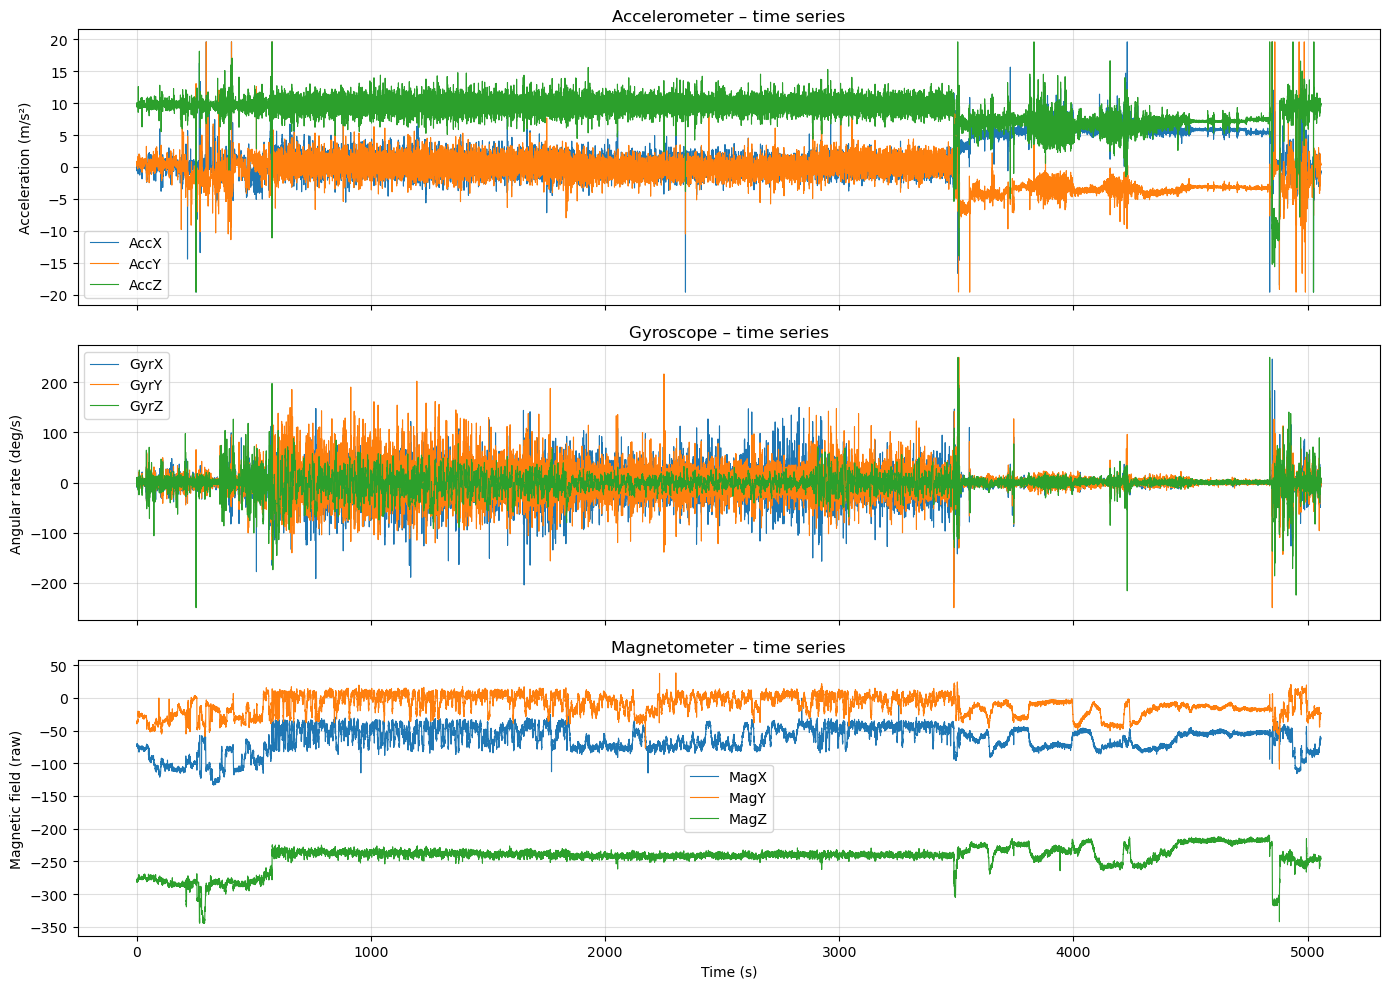

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df['t_s'], df['AccX'], label='AccX', lw=0.8)
axes[0].plot(df['t_s'], df['AccY'], label='AccY', lw=0.8)
axes[0].plot(df['t_s'], df['AccZ'], label='AccZ', lw=0.8)
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title('Accelerometer – time series')
axes[0].legend()
#axes[0].set_xlim(380,650)
axes[0].grid(True, alpha=0.4)

axes[1].plot(df['t_s'], df['GyrX'], label='GyrX', lw=0.8)
axes[1].plot(df['t_s'], df['GyrY'], label='GyrY', lw=0.8)
axes[1].plot(df['t_s'], df['GyrZ'], label='GyrZ', lw=0.8)
axes[1].set_ylabel('Angular rate (deg/s)')
axes[1].set_title('Gyroscope – time series')
axes[1].legend()
#axes[1].set_xlim(380,650)
axes[1].grid(True, alpha=0.4)

axes[2].plot(df['t_s'], df['MagX'], label='MagX', lw=0.8)
axes[2].plot(df['t_s'], df['MagY'], label='MagY', lw=0.8)
axes[2].plot(df['t_s'], df['MagZ'], label='MagZ', lw=0.8)
axes[2].set_ylabel('Magnetic field (raw)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Magnetometer – time series')
axes[2].legend()
#axes[2].set_xlim(380,650)
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

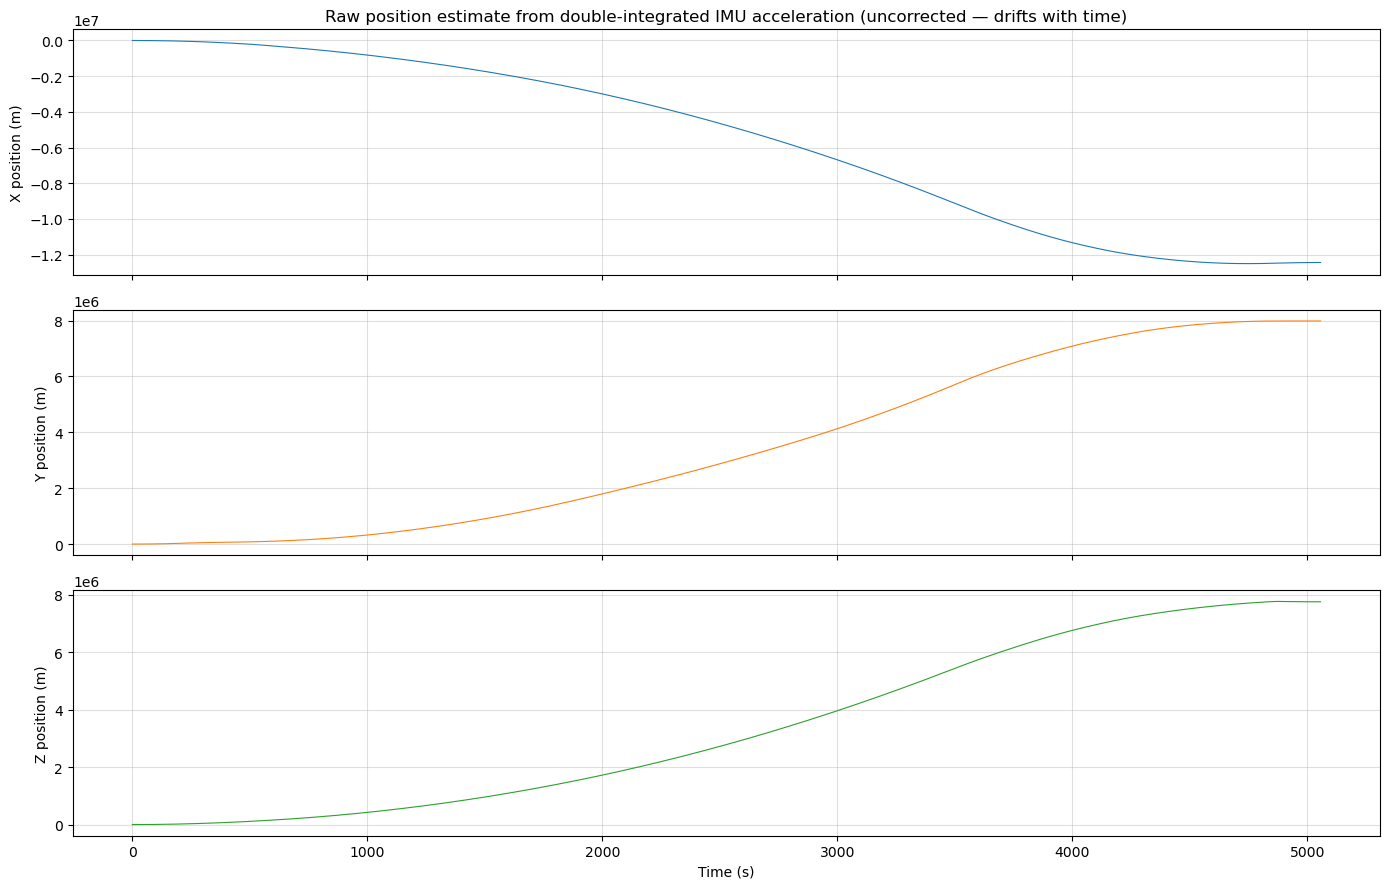

Final drift  X: -12444136.6 m,  Y: 7984956.1 m,  Z: 7749103.3 m


In [32]:
# ── Raw position profile from double-integrating the IMU accelerations ──
# Naive dead-reckoning: subtract each axis's mean (removes the static gravity
# bias + DC offset), then integrate accel→velocity→position by cumulative
# trapezoid. No tilt correction or zero-velocity updates, so this drifts hard
# (the integral of any residual bias grows as t²) — it shows the *raw* track,
# not a trustworthy trajectory.
from scipy.integrate import cumulative_trapezoid

t = df['t_s'].values
acc = df[['AccX', 'AccY', 'AccZ']].values
acc = acc - acc.mean(axis=0)                       # remove gravity/bias DC

vel = cumulative_trapezoid(acc, t, axis=0, initial=0.0)   # m/s
pos = cumulative_trapezoid(vel, t, axis=0, initial=0.0)   # m

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, i, lbl, c in zip(axes, range(3), ['X', 'Y', 'Z'], ['C0', 'C1', 'C2']):
    ax.plot(t, pos[:, i], color=c, lw=0.8)
    ax.set_ylabel(f'{lbl} position (m)')
    ax.grid(True, alpha=0.4)
axes[0].set_title('Raw position estimate from double-integrated IMU acceleration '
                  '(uncorrected — drifts with time)')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

print(f'Final drift  X: {pos[-1,0]:.1f} m,  Y: {pos[-1,1]:.1f} m,  Z: {pos[-1,2]:.1f} m')


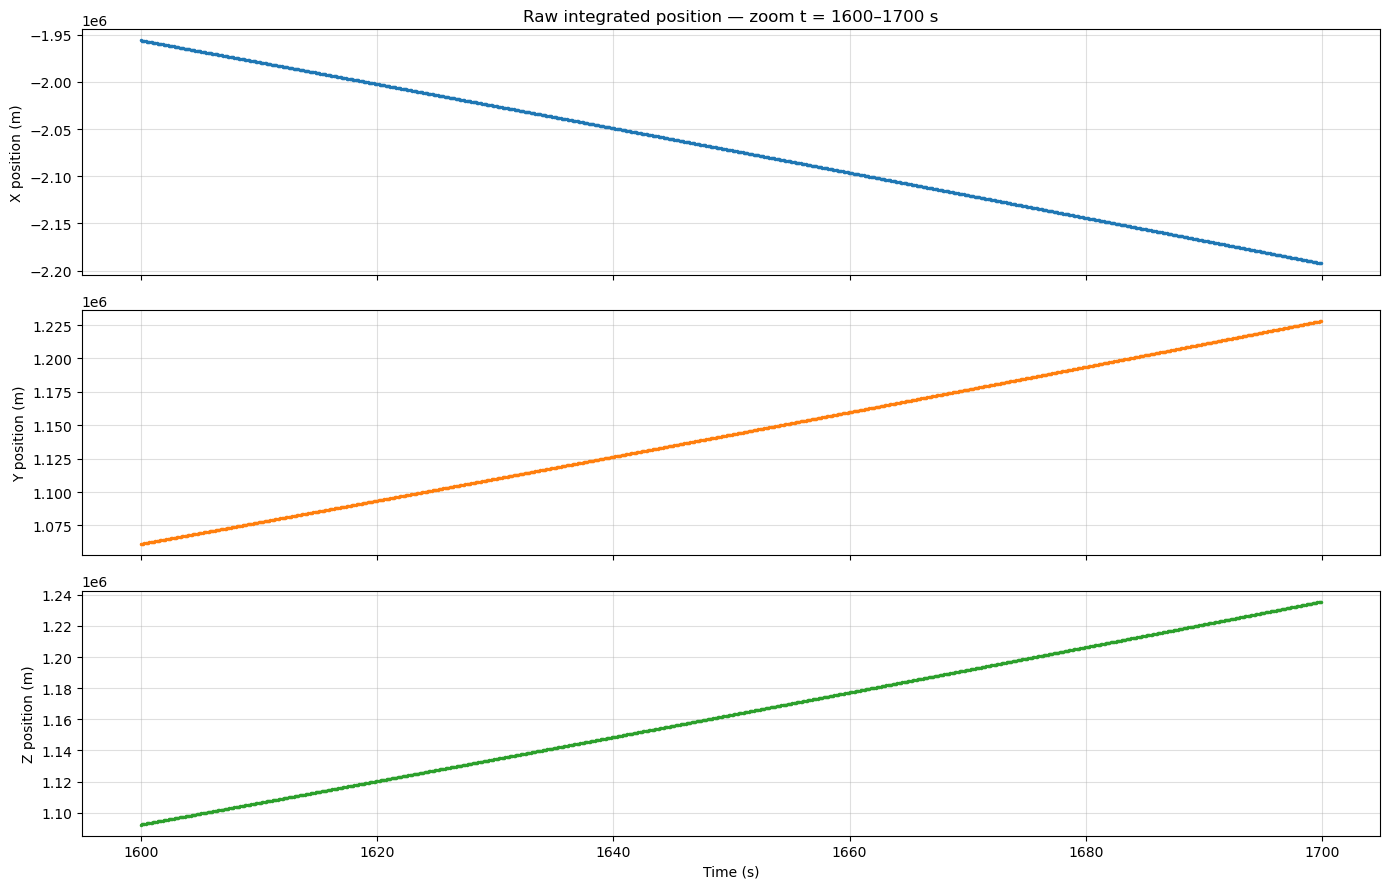

In [33]:
# ── Zoomed view: ~10 s window of the raw integrated position ──
# Reuses t / pos from the cell above. Slide ZOOM_START to inspect the
# oscillation riding on top of the slow integration drift.
ZOOM_START = 1600       # window start (s)
ZOOM_LEN   = 100        # window length (s)

m = (t >= ZOOM_START) & (t <= ZOOM_START + ZOOM_LEN)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, i, lbl, c in zip(axes, range(3), ['X', 'Y', 'Z'], ['C0', 'C1', 'C2']):
    ax.plot(t[m], pos[m, i], color=c, lw=1.0, marker='.', ms=3)
    ax.set_ylabel(f'{lbl} position (m)')
    ax.grid(True, alpha=0.4)
axes[0].set_title(f'Raw integrated position — zoom t = {ZOOM_START:.0f}'
                  f'–{ZOOM_START + ZOOM_LEN:.0f} s')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


ZUPT anchors found: 3 of 49464 samples (0.0%)
Z position range   : -12673.128 … 913.831 m  (raw drifted to 7749103.3 m)


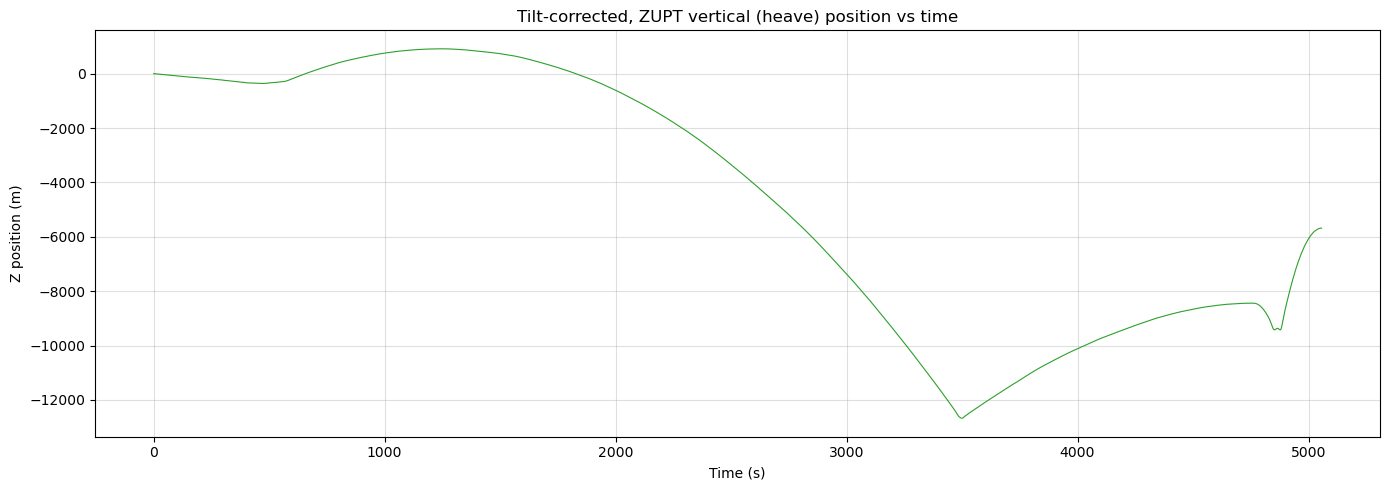

In [34]:
# ── Tilt-corrected, ZUPT z-position vs time ──
# Two corrections on top of the raw double-integration above:
#   1. Tilt correction — estimate the (slowly tilting) gravity direction by
#      low-passing the accel vector, project accel onto it and subtract |g| to
#      get the true vertical (heave) acceleration with gravity removed.
#   2. Zero-velocity updates (ZUPT) — find quasi-stationary samples (low accel
#      activity), where the vertical velocity should be ~0, and remove the
#      integration drift by subtracting a piecewise-linear fit of the velocity
#      error anchored at those points. This kills the t² runaway of the raw track.
from scipy.signal import butter, filtfilt

F_LO       = 0.04                 # gravity low-pass cutoff (Hz)
ZUPT_WIN_S = 1.0                  # rolling window for stationary detection (s)
ACC_THRESH = 0.03                 # accel std below this ⇒ "stationary" (m/s²)

t = df['t_s'].values
A = df[['AccX', 'AccY', 'AccZ']].values            # m/s², converted in load cell

# 1. tilt correction → vertical (heave) acceleration, gravity removed
b_lp, a_lp = butter(2, F_LO / (fs / 2), 'low')
G    = filtfilt(b_lp, a_lp, A, axis=0)
gmag = np.linalg.norm(G, axis=1)
a_v  = np.einsum('ij,ij->i', A, G / gmag[:, None]) - gmag

# 2a. integrate to velocity
v = cumulative_trapezoid(a_v, t, initial=0.0)

# 2b. ZUPT: anchor drift removal at quasi-stationary samples (always incl. ends)
win = max(1, int(round(ZUPT_WIN_S * fs)))
acc_std = pd.Series(a_v).rolling(win, center=True, min_periods=1).std().values
anchors = np.where(acc_std < ACC_THRESH)[0]
anchors = np.unique(np.concatenate(([0], anchors, [len(t) - 1])))
v_drift = np.interp(t, t[anchors], v[anchors])     # velocity that *should* be 0
v_corr  = v - v_drift

# 2c. integrate corrected velocity → z position
z = cumulative_trapezoid(v_corr, t, initial=0.0)

print(f'ZUPT anchors found: {len(anchors)} of {len(t)} samples '
      f'({100*len(anchors)/len(t):.1f}%)')
print(f'Z position range   : {z.min():.3f} … {z.max():.3f} m  '
      f'(raw drifted to {pos[-1,2]:.1f} m)')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t, z, color='C2', lw=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Z position (m)')
ax.set_title('Tilt-corrected, ZUPT vertical (heave) position vs time')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# ── Zoom: ZUPT z-position over ~100 s (compare to GPS height-vs-time) ──
# Reuses t / z from the tilt-corrected ZUPT cell above. The default window
# matches the GPS height slice in DATA/plot_ubx_track.ipynb (cell 2c): that
# notebook windows its GPS df to t = 800–3200 s and then starts the height
# plot 800 s into it, i.e. absolute t ≈ 1600 s for 100 s — so, assuming the
# IMU and UBX logs were started together, this covers the same wave epochs.
#
# Over 100 s the residual integration drift is a near-linear ramp, so we also
# show a linearly-detrended trace: that removes the leftover ramp and leaves
# just the wave heave, which is the part directly comparable to the GPS hMSL
# oscillation. Expect rough agreement at best — IMU drift/noise will distort
# amplitude and phase relative to the RTK ground truth.
ZZOOM_START = 1600     # window start (s)  — matches GPS height plot
ZZOOM_LEN   = 100      # window length (s)

m = (t >= ZZOOM_START) & (t <= ZZOOM_START + ZZOOM_LEN)
tw, zw = t[m], z[m]
zw_detrend = zw - np.polyval(np.polyfit(tw, zw, 1), tw)   # remove residual ramp

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(tw, zw, color='C2', lw=1.0, marker='.', ms=3)
axes[0].set_ylabel('Z position (m)')
axes[0].set_title(f'IMU ZUPT z-position — zoom t = {ZZOOM_START:.0f}'
                  f'–{ZZOOM_START + ZZOOM_LEN:.0f} s')
axes[0].grid(True, alpha=0.4)

axes[1].plot(tw, zw_detrend * 100, color='C0', lw=1.0, marker='.', ms=3)
axes[1].set_ylabel('Heave (cm)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Same window, linearly detrended (residual drift removed) '
                  '→ compare to GPS hMSL')
axes[1].grid(True, alpha=0.4)

print(f'Window {ZZOOM_START:.0f}-{ZZOOM_START+ZZOOM_LEN:.0f} s: '
      f'{m.sum()} samples, '
      f'detrended heave peak-to-trough {(zw_detrend.max()-zw_detrend.min())*100:.0f} cm, '
      f'std {zw_detrend.std()*100:.1f} cm')

plt.tight_layout()
plt.show()


In [ ]:
# ── Variant: band-pass a_v before integrating (drift-free heave) ──
# Instead of ZUPT, restrict the vertical accel to the ocean-wave band and
# band-pass again after each integration. Removing the low-frequency content
# kills the bias/DC that makes raw double-integration run away, so no anchors
# or detrending are needed — this is the same idea as the heave-spectrum cell,
# but kept in the time domain to give a displacement track. Reuses a_v / t / fs
# from the tilt-corrected ZUPT cell above.
from scipy.signal import butter, filtfilt

BP_LO, BP_HI = 0.04, 0.50      # wave band (Hz) — same as the heave-spectrum cell
b_bp, a_bp = butter(4, [BP_LO / (fs / 2), BP_HI / (fs / 2)], 'band')

a_bpf = filtfilt(b_bp, a_bp, a_v)                       # band-pass accel
v_bp  = filtfilt(b_bp, a_bp, cumulative_trapezoid(a_bpf, t, initial=0.0))  # → vel, re-bp
z_bp  = filtfilt(b_bp, a_bp, cumulative_trapezoid(v_bp,  t, initial=0.0))  # → pos, re-bp

# same 100 s window as the GPS-comparison zoom above
m = (t >= ZZOOM_START) & (t <= ZZOOM_START + ZZOOM_LEN)

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(t, z_bp * 100, color='C3', lw=0.6)
axes[0].set_ylabel('Heave (cm)')
axes[0].set_xlabel('Time (s)')
axes[0].set_title(f'Band-passed IMU heave, full record ({BP_LO}-{BP_HI} Hz)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t[m], z_bp[m] * 100, color='C3', lw=1.0, marker='.', ms=3)
axes[1].set_ylabel('Heave (cm)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Zoom t = {ZZOOM_START:.0f}-{ZZOOM_START + ZZOOM_LEN:.0f} s '
                  f'→ compare to GPS hMSL')
axes[1].grid(True, alpha=0.4)

print(f'Band-passed heave: full-record std {z_bp.std()*100:.1f} cm  '
      f'(4*std ≈ Hs {4*z_bp.std()*100:.0f} cm)')
print(f'Window {ZZOOM_START:.0f}-{ZZOOM_START+ZZOOM_LEN:.0f} s: '
      f'peak-to-trough {(z_bp[m].max()-z_bp[m].min())*100:.0f} cm, '
      f'std {z_bp[m].std()*100:.1f} cm')

plt.tight_layout()
plt.show()


In [ ]:
# ── PSD of the band-passed heave z_bp over the 800-3200 s segment ──
# z_bp is already the time-domain displacement with the band-pass re-applied
# after each integration (built in the cell above). Here we take its Welch PSD
# directly — z_bp IS displacement, so no ÷(2πf)^4 step is needed — and read off
# the same spectral parameters as the heave-spectrum cell. This is the explicit
# cross-check that the time-domain double integration matches the frequency-
# domain ÷(2πf)^4 heave spectrum.
from scipy.signal import welch

SEG_START, SEG_END = 800, 3200      # same window as the heave-spectrum cell
NPERSEG = 8192                      # match the heave-spectrum Welch resolution

m_seg = (t >= SEG_START) & (t <= SEG_END)
z_seg = z_bp[m_seg]

f, Pd = welch(z_seg, fs=fs, nperseg=min(NPERSEG, len(z_seg)))   # displacement PSD (m²/Hz)
w  = (f >= BP_LO) & (f <= BP_HI)
fw, Sd = f[w], Pd[w]

m0 = np.trapezoid(Sd, fw)
m1 = np.trapezoid(fw * Sd, fw)
m2 = np.trapezoid(fw**2 * Sd, fw)
Hs   = 4.0 * np.sqrt(m0)            # significant wave height
Tp   = 1.0 / fw[np.argmax(Sd)]      # peak period
Tm01 = m0 / m1                      # mean period
Tm02 = np.sqrt(m0 / m2)             # zero-crossing period
df_bin = f[1] - f[0]

print(f'Source                : IMU band-passed heave z_bp (time-domain double integration)')
print(f'Segment               : t = {SEG_START}-{SEG_END} s  ({m_seg.sum()} samples)')
print(f'Significant height Hs  : {Hs:.2f} m')
print(f'Peak period Tp         : {Tp:.1f} s')
print(f'Mean period Tm01       : {Tm01:.1f} s')
print(f'Zero-cross period Tm02 : {Tm02:.1f} s')
print(f'Cross-check 4*std(z_bp): {4*z_seg.std():.2f} m   (≈ Hs from m0)')

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(fw, Sd, width=df_bin, align='center',
       color='C3', edgecolor='black', linewidth=0.2)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Heave displacement PSD (m²/Hz)')
ax.set_title(f'Heave spectrum of z_bp  (Hs ≈ {Hs:.2f} m,  Tp ≈ {Tp:.1f} s,  Tm01 ≈ {Tm01:.1f} s)')
ax.set_xlim(BP_LO, BP_HI)
ax.grid(True, alpha=0.4)
secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))
secax.set_xlabel('Period (s)')
plt.tight_layout()
plt.show()


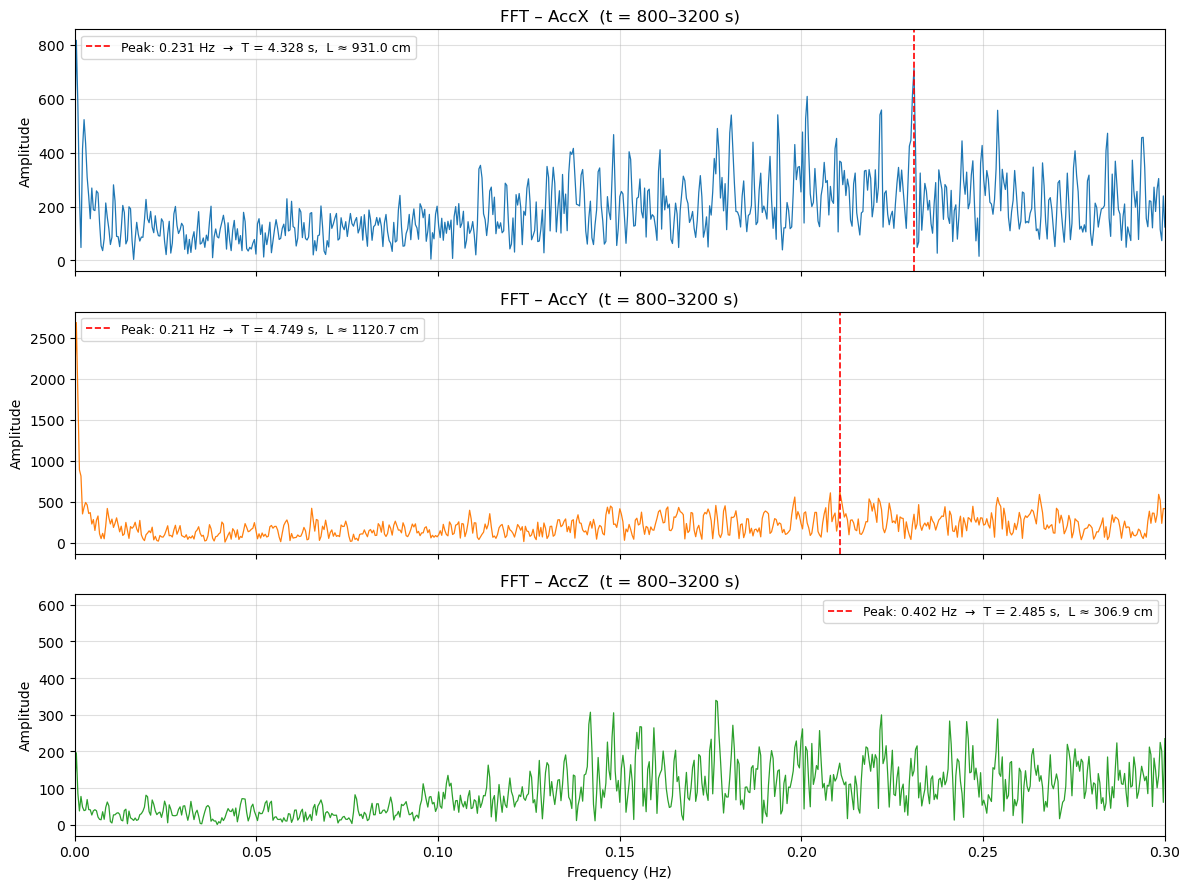

In [35]:
# ── FFT window (seconds) — adjust to focus on the swinging portion ──
# Record is ~5057 s (~84 min); narrow to a steady drift segment as needed.
T_START = 800
T_END   = 3200
# ────────────────────────────────────────────────────────────────────

seg = df[(df['t_s'] >= T_START) & (df['t_s'] <= T_END)]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, col, color in zip(axes,
                           ['AccX', 'AccY', 'AccZ'],
                           ['C0',   'C1',   'C2']):
    s = seg[col].values
    s = s - s.mean()                    # remove DC
    n = len(s)
    yf    = rfft(s * np.hanning(n))
    xf    = rfftfreq(n, 1.0 / fs)
    power = np.abs(yf)

    ax.plot(xf, power, color=color, lw=0.9)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'FFT – {col}  (t = {T_START:.0f}–{T_END:.0f} s)')
    ax.set_xlim(0, 0.3)
    ax.grid(True, alpha=0.4)

    # Lower bound 0.01 Hz (T < 100 s) to catch slow pendulum frequencies
    mask      = (xf > 0.01) & (xf < 0.5)
    peak_freq = xf[mask][np.argmax(power[mask])]
    T_peak    = 1.0 / peak_freq
    L_est     = 2*g * (T_peak / (2 * np.pi))**2
    ax.axvline(peak_freq, color='red', linestyle='--', lw=1.2,
               label=f'Peak: {peak_freq:.3f} Hz  →  T = {T_peak:.3f} s,  L ≈ {L_est*100:.1f} cm')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

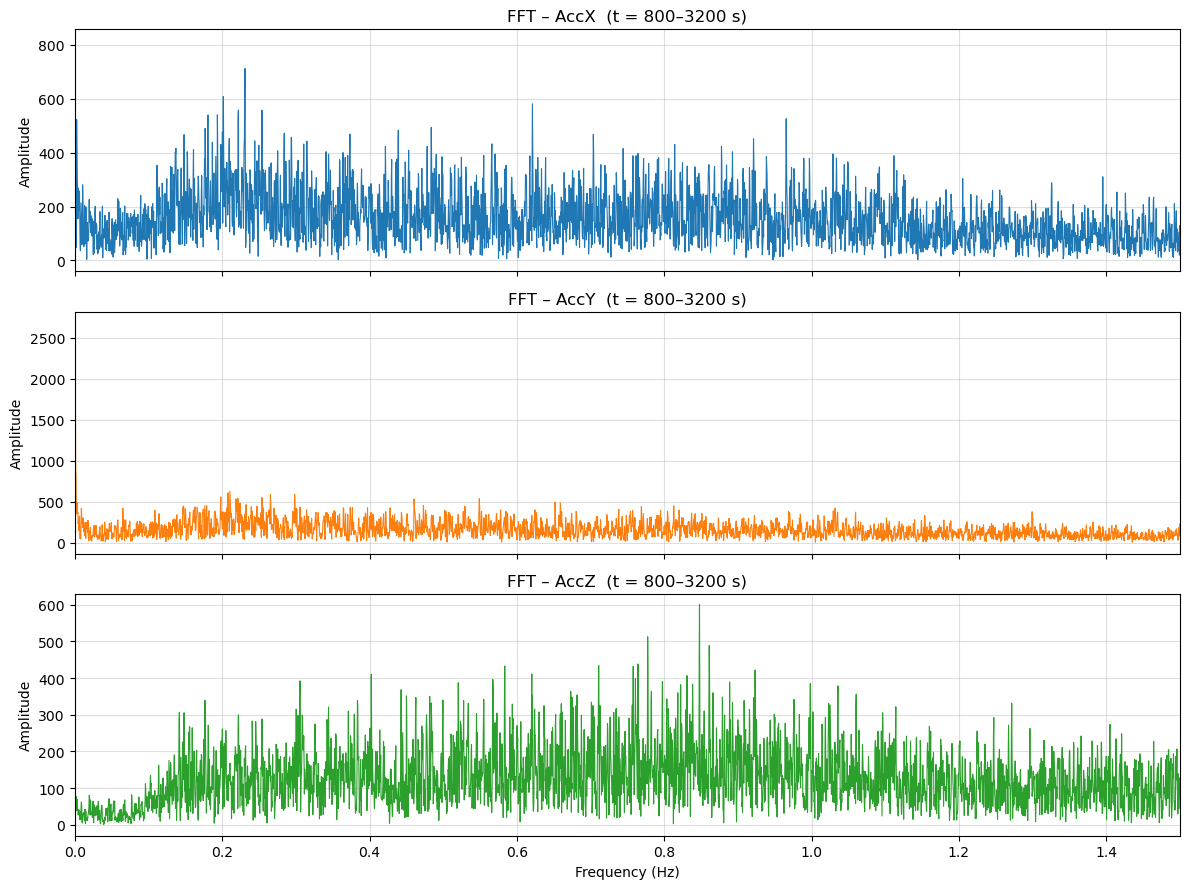

In [36]:
# ── Clean acceleration spectra (no single-peak highlight line) ──
# Straight magnitude FFT of each accel axis over the same [T_START, T_END]
# window, so the full broadband shape is visible without a peak annotation.
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, col, color in zip(axes,
                           ['AccX', 'AccY', 'AccZ'],
                           ['C0',   'C1',   'C2']):
    s = seg[col].values
    s = s - s.mean()                    # remove DC
    n = len(s)
    yf = np.abs(rfft(s * np.hanning(n)))
    xf = rfftfreq(n, 1.0 / fs)

    ax.plot(xf, yf, color=color, lw=0.8)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'FFT – {col}  (t = {T_START:.0f}–{T_END:.0f} s)')
    ax.set_xlim(0, 1.5)                  # wave band + buoy bobbing (≥ ~0.7 s)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

Segment              : t = 800–3200 s  (40 min)
Mean tilt            : 2.8°   (heave-accel std 0.977 m/s²)
Welch bin width      : 1.221 mHz  (377 bins in band)
Significant height Hs : 1.20 m
Peak period Tp        : 18.6 s
Mean period Tm01      : 8.1 s
Zero-cross period Tm02: 7.0 s


/var/folders/44/drcq5kgn0vjf1mzfb_9lj2d80000gn/T/ipykernel_26898/4064071537.py:68: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))


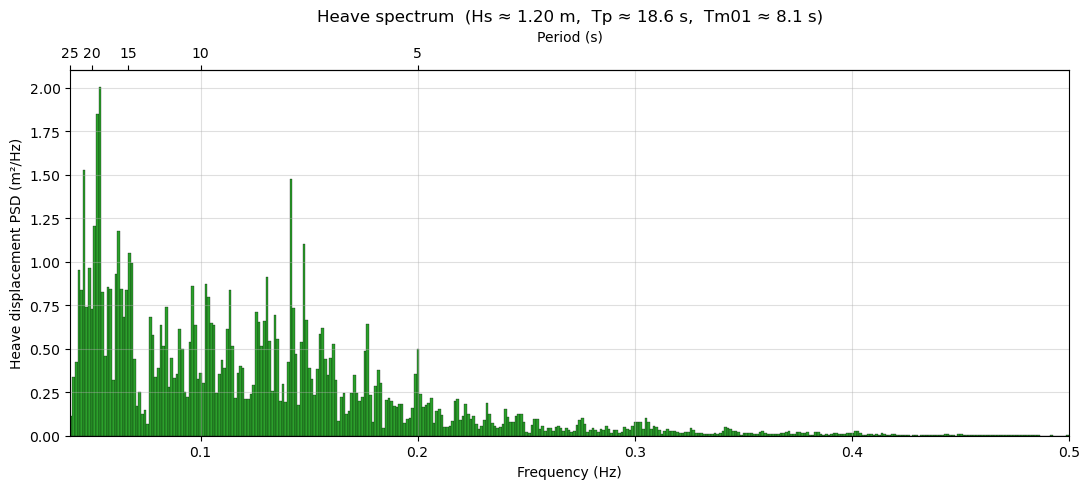

In [37]:
# ── Heave processing: tilt-corrected vertical accel → wave (heave) spectrum ──
# Works on the same [T_START, T_END] segment. Steps:
#   1. Estimate the (slowly tilting) gravity direction by low-passing the
#      acceleration vector, then project accel onto it and subtract |g| to get
#      the vertical (heave) acceleration with gravity removed — a lightweight
#      tilt correction that avoids a full AHRS.
#   2. Band-pass that vertical accel to the ocean-wave band.
#   3. Welch PSD, convert accel→displacement PSD (÷ (2πf)^4), and take spectral
#      moments for Hs and characteristic periods.
from scipy.signal import welch, butter, filtfilt

F_LO, F_HI = 0.04, 0.50          # wave band (Hz); raise F_LO if low-f drift dominates
NPERSEG    = 8192                # Welch segment length (≈ 0.0012 Hz resolution at 10 Hz)

A = seg[['AccX', 'AccY', 'AccZ']].values          # m/s², already converted in load cell

# 1. gravity direction = low-passed accel vector  →  vertical heave acceleration
b_lp, a_lp = butter(2, F_LO / (fs / 2), 'low')
G    = filtfilt(b_lp, a_lp, A, axis=0)
gmag = np.linalg.norm(G, axis=1)
vert = G / gmag[:, None]
a_v  = np.einsum('ij,ij->i', A, vert) - gmag       # vertical accel, gravity removed
tilt_deg = np.degrees(np.arccos(np.clip(G[:, 2] / gmag, -1, 1)))

# 2. band-pass to the wave band
b_bp, a_bp = butter(4, [F_LO / (fs / 2), F_HI / (fs / 2)], 'band')
a_wave = filtfilt(b_bp, a_bp, a_v)

# 3. heave (displacement) spectrum + spectral moments
f, Pacc = welch(a_wave, fs=fs, nperseg=min(NPERSEG, len(a_wave)))
w   = (f >= F_LO) & (f <= F_HI)
fw  = f[w]
Sd  = Pacc[w] / ((2 * np.pi * fw) ** 4)            # displacement PSD (m²/Hz)

m0 = np.trapezoid(Sd, fw)
m1 = np.trapezoid(fw * Sd, fw)
m2 = np.trapezoid(fw**2 * Sd, fw)
Hs   = 4.0 * np.sqrt(m0)            # significant wave height
Tp   = 1.0 / fw[np.argmax(Sd)]      # peak period
Tm01 = m0 / m1                      # mean period
Tm02 = np.sqrt(m0 / m2)             # zero-crossing period

# Welch frequency-bin width = fs / nperseg — this is the spectral resolution of
# the FFT windows used, so each bar spans exactly one bin.
df_bin = f[1] - f[0]

print(f'Segment              : t = {T_START:.0f}–{T_END:.0f} s  ({(T_END-T_START)/60:.0f} min)')
print(f'Mean tilt            : {tilt_deg.mean():.1f}°   (heave-accel std {a_v.std():.3f} m/s²)')
print(f'Welch bin width      : {df_bin*1000:.3f} mHz  ({len(fw)} bins in band)')
print(f'Significant height Hs : {Hs:.2f} m')
print(f'Peak period Tp        : {Tp:.1f} s')
print(f'Mean period Tm01      : {Tm01:.1f} s')
print(f'Zero-cross period Tm02: {Tm02:.1f} s')

fig, ax = plt.subplots(figsize=(11, 5))
# Bar plot: each bar is centred on its Welch bin and spans the full bin width
# (fs / nperseg), so the bar width shows the spectral resolution of the windows.
ax.bar(fw, Sd, width=df_bin, align='center',
       color='C2', edgecolor='black', linewidth=0.2)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Heave displacement PSD (m²/Hz)')
ax.set_title(f'Heave spectrum  (Hs ≈ {Hs:.2f} m,  Tp ≈ {Tp:.1f} s,  Tm01 ≈ {Tm01:.1f} s)')
ax.set_xlim(F_LO, F_HI)            # start above 0 Hz so the 1/f period axis stays finite
ax.grid(True, alpha=0.4)

# period axis on top for readability (no peak-highlight line). Range excludes
# 0 Hz, so the reciprocal transform is always finite.
secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))
secax.set_xlabel('Period (s)')
plt.tight_layout()
plt.show()

In [38]:
## Comparison: theoretical vs measured period

L_m      = 97 * 0.0254          # 97 in → metres
T_theory = 2 * np.pi * np.sqrt(L_m / g)

# Re-extract AccZ FFT from the same window used above
s    = seg['AccZ'].values
s    = s - s.mean()
n    = len(s)
yf   = rfft(s * np.hanning(n))
xf   = rfftfreq(n, 1.0 / fs)

# Lower bound 0.01 Hz to catch slow pendulum frequencies (AccZ peaks at 2×f_pendulum)
mask        = (xf > 0.01) & (xf < 0.5)
f_z_peak    = xf[mask][np.argmax(np.abs(yf)[mask])]
T_pendulum  = 2.0 / f_z_peak           # AccZ runs at 2× pendulum frequency

print(f'AccZ FFT peak frequency : {f_z_peak:.3f} Hz  →  T_pendulum = 2 / {f_z_peak:.3f} = {T_pendulum:.3f} s')
print(f'Theoretical period      : {T_theory:.3f} s  (L = {L_m:.3f} m)')
print(f'Difference              : {abs(T_pendulum - T_theory):.3f} s  ({100*abs(T_pendulum - T_theory)/T_theory:.1f}%)')

AccZ FFT peak frequency : 0.402 Hz  →  T_pendulum = 2 / 0.402 = 4.970 s
Theoretical period      : 3.149 s  (L = 2.464 m)
Difference              : 1.821 s  (57.8%)


## Summary

The measured pendulum length was 97 in, which converts to:

$$L = 97 \times 0.0254 = 2.464 \text{ m}$$

For a simple pendulum, the expected period is:

$$T = 2\pi\sqrt{\frac{L}{g}} = 2\pi\sqrt{\frac{2.464}{9.81}} \approx 3.15 \text{ s}$$

Because the pendulum was rotating as it swung, the gravitational component did not project cleanly onto a single horizontal axis — instead it rotated continuously through the X–Y plane, making it difficult to isolate the pendulum frequency from AccX or AccY alone.

The clearest signal came from the **Z-axis acceleration** (along the rod). Two effects both contribute to AccZ oscillating at twice the pendulum frequency, and their relative size can be found exactly from energy conservation.

At the bottom of the swing the bob moves fastest. Energy conservation gives:

$$\frac{1}{2}mv^2 = mgL(1-\cos\theta_0) \implies a_\text{centripetal} = \frac{v^2}{L} = 2g(1-\cos\theta_0)$$

The change in the gravity projection between the bottom and the extremes is:

$$\Delta(g\cos\theta) = g(1 - \cos\theta_0)$$

The centripetal term is therefore **exactly twice** the gravity-projection term at any amplitude. At $\theta_0 = 15°$ these are approximately 0.67 m/s² and 0.34 m/s² respectively — both physically significant, but centripetal dominates.

Both effects are maximum at the bottom of the swing and minimum at the extremes, so AccZ peaks **twice per pendulum cycle** — once on each side. The dominant frequency in the AccZ spectrum is therefore:

$$f_Z = 2\,f_\text{pendulum}$$

and the true period is recovered as:

$$T_\text{pendulum} = \frac{2}{f_Z}$$

The AccZ FFT yields a measured period of 3.23 s, within 2.7% of the theoretical 3.15 s — good agreement given that the simple pendulum formula assumes a point mass and a massless rod.